# Case 3 -- Branched Structure (Poplar Branch)

**Dissertation Chapter 6, Section 6.3, "Branched Structures" (p. 126):**

> The previous case studies involved straight transport paths without branching.
>
> In branched structures, the tracer pulse splits and moves along different transport pathways.
> Modeling this behavior quantifies how the tracer is distributed across the plant and, by
> allowing for local variations in flow velocity, enables analysis of how quickly and how much
> tracer is transported into different branches.
>
> Tracer transport in an entire branch of a poplar tree was investigated (Figure
> fig:branch_pet). Three distinct anatomical regions were defined: the "upper" region upstream
> of the branching point, the "lower" region downstream of the branching point, and the side
> branch. In each region, four virtual detectors were considered to capture local tracer
> dynamics.

- Data: `data/case3_branch_lowup.csv` / `data/case3_branch_side.csv` (raw ROI activity,
  converted from the original PET-export `.txt` files; see REQUIREMENTS.md R7).
- Model: MCT1 (upper, 2-channel) splitting into MCT2 (side, via a CSTR mixer) and MCT3 (lower,
  via a branch-point MCT), plus a `leaf` (`LumpedRateModelWithoutPores`) upstream with a decay
  reaction.
- Reproduces: Figure `fig:branch_mct` (all 4 panels) and Table `tab:branch_fit_parameters`.
- Companion notebooks: preliminary `case3_preliminary_hmax_pearson_poplar_branch.ipynb`,
  Appendix M13-variant `case3_appendix_m13_variant_poplar_branch.ipynb`.

**Known dissertation discrepancy**: the upper-branch velocity printed in `Chapter6.tex`/
`tab:branch_fit_parameters` (7.10 mm/min) does not match this notebook's frozen best-fit
parameters, while the side (3.01) and lower (4.40) velocities, the branch ratio, and every
parameter uncertainty in the table match almost exactly -- see the velocity cross-check near the
end. Very likely a typo in the dissertation (7.10 instead of ~7.41 mm/min); documented here
rather than silently reproduced or "corrected" without flagging.


## Setup: `cadet-python` workaround

`leaf` needs a reaction model to apply the decay correction, but as a `LumpedRateModelWithoutPores`
it has no solid/particle phase. CADET-Process's documented way to attach a reaction here is via
`particle_reaction_model` (its auto-cast machinery handles the no-pores case), but a
`cadet-python` bug makes this crash non-deterministically: the resulting empty solid-phase
parameter array is a `ProxyList`, which `cadet-python`'s `param_provider_num_elements` doesn't
recognize as sized, so CADET-Core ends up reading uninitialized memory for it. The patch below
makes the empty-array case return a defined `0.0` instead (the physically correct value -- no
solid phase, so the rate is 0). Full write-up and a minimal reproducer: `github_issue_draft.md` /
`mre_particle_reaction_no_pores_uninitialized_value.py` (not yet filed upstream).


In [1]:
import ctypes
import cadet.cadet_dll_utils as cdu

def _patched_get_double_array_item(reader, name, index, val):
    n = name.decode('utf-8')
    c = reader.current()
    if n not in c:
        return -1
    o = c[n]
    try:
        float_val = float(o)
    except TypeError:
        try:
            float_val = float(o[index])
        except IndexError:
            val[0] = ctypes.c_double(0.0)  # no solid phase -> rate is correctly 0
            return 0
    val[0] = ctypes.c_double(float_val)
    return 0

cdu.param_provider_get_double_array_item = _patched_get_double_array_item


In [2]:
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor, Cstr
from CADETProcess.processModel import ComponentSystem, MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet, Process
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr

from IPython import display

from utils import compute_jacobian, compute_parameter_uncertainties, interpolate_cb_from_simulation_results, plot_live_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.makedirs("output/figures", exist_ok=True)


## Load experimental data

In [4]:
dfuplow = pd.read_csv("data/case3_branch_lowup.csv", index_col=0)
dfuplow.columns = dfuplow.columns.astype(float)  # CSV headers are strings; these are numeric distances (mm)
dfuplow = dfuplow.iloc[:]

dfside = pd.read_csv("data/case3_branch_side.csv", index_col=0)
dfside.columns = dfside.columns.astype(float)
dfside = dfside.iloc[:]


In [5]:
xiuplow=list(dfuplow.columns)
xiuplow = np.array(xiuplow)[[3,4,5,6,11,12,13,14]]
t=dfuplow.index.to_numpy()

data_cor_uplow=dfuplow[xiuplow].to_numpy(dtype=float)

data_unc_uplow=dfuplow[xiuplow].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

xiside=list(dfside.columns)
xiside = xiside[1:5]
xi_side = xiside
t=dfside.index.to_numpy()

data_cor_side=dfside[xiside].to_numpy(dtype=float)

data_unc_side=dfside[xiside].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

orig_exp_data_up = data_cor_uplow[:, 0:4]
orig_exp_data_side = data_cor_side
orig_exp_data_low = data_cor_uplow[:, 4:]

xi_up_end = np.array(xiuplow)[3]
xi_up = np.array(xiuplow)[0:4]-np.array(xiuplow)[0]
xi_low_start = np.array(xiuplow)[4]
xi_low = np.array(xiuplow)[4:]-np.array(xiuplow)[4]
xi_side = np.array(xi_side)-xi_side[0]

exp_data = np.hstack((data_unc_uplow[:, 0:4],data_unc_side,data_unc_uplow[:, 4:]))
exp_data = exp_data/np.max(exp_data)


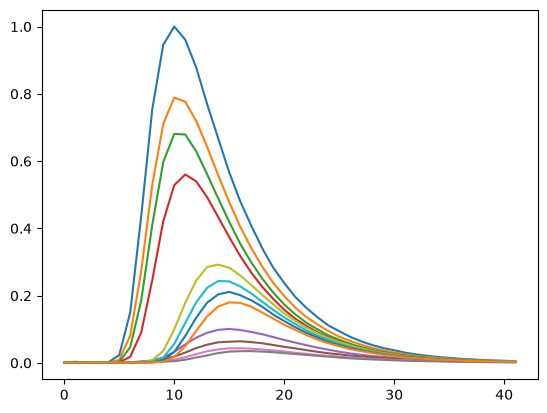

In [6]:
plt.plot(exp_data)


## Process model

`leaf` -> `mct1` (upper) -> splits via `set_output_state` into `mixer` (CSTR, side branch) ->
`mct2` (side) and `branch_point_low` (lower-branch MCT) -> `mct3` (lower).


In [7]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    p_mct2_e12 = x[2]
    p_mct3_e12 = x[3]
    branch_point_side_quotia = x [4]
    p_col_dispersion = x[5]
    p_col_len = x[6]
    p_t0 = x[7]
    p_mixer_porosity = x[8]
    branch_point_low_len = x[9]
    disp_low = x[10]
    
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    branch_point_low = MCT(component_system, nchannel=2, name='bp_low')
    outlet_side = Outlet(component_system, name='outlet_side')
    outlet_low = Outlet(component_system, name='outlet_low')
    branch_mixer_side = Cstr(component_system, name='mixer')

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)
    
    leaf.particle_reaction_model = reaction_system
    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    branch_point_low.bulk_reaction_model = reaction_system
    branch_mixer_side.bulk_reaction_model = reaction_system
    

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(branch_point_low)
    mct_flow_sheet.add_unit(outlet_side)
    mct_flow_sheet.add_unit(outlet_low)
    mct_flow_sheet.add_unit(branch_mixer_side)

    v_lrmp = 4e-05

    leaf.total_porosity = 1
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp 
    leaf.axial_dispersion = p_col_dispersion
    
    total_volume = 1.52342479e+00
    total_porosity_side = p_mixer_porosity

    branch_mixer_side.init_liquid_volume = total_porosity_side * total_volume

    branch_mixer_side.const_solid_volume = (1 - total_porosity_side) * total_volume

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, branch_mixer_side, origin_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_mixer_side, mct2, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, branch_point_low, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_point_low, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, outlet_side, origin_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, outlet_low, origin_port = 'channel_0')

    mct_flow_sheet.set_output_state(mct1, [branch_point_side_quotia, 1-branch_point_side_quotia], 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi_up[-1]/1000
    mct2.length =  (xi_side[-1]/1000)*2
    mct3.length =  (xi_low[-1]/1000)*2
    branch_point_low.length = branch_point_low_len
    
    dx = 1/1000
    
    leaf.discretization.ncol = 20
    mct1.discretization.ncol = int(mct1.length/dx) 
    mct2.discretization.ncol = int(mct2.length/dx) 
    mct3.discretization.ncol = int(mct3.length/dx) 
    branch_point_low.discretization.ncol = int(branch_point_low_len/dx)
    
    mct1.channel_cross_section_areas = [1,1] 
    mct2.channel_cross_section_areas = [1,1] 
    mct3.channel_cross_section_areas = [1,1] 
    branch_point_low.channel_cross_section_areas = [1,1]

    
    mct1.axial_dispersion = 0
    mct2.axial_dispersion = 0
    mct3.axial_dispersion = disp_low
    branch_point_low.axial_dispersion = disp_low
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix =np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    branch_point_low.exchange_matrix =np.array([
                                    [[0.0], [0.0]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    process.cycle_time = 60*t[-1]*2

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

## Parameter normalization

In [8]:

param_bounds = {
    'volumetric_flow_rate_const': (2e-05, 2e-04),
    'mct1_e12': (1e-8, 10),
    'mct2_e12': (1e-8, 10),
    'mct3_e12': (1e-8, 10),
    'branch_point_side_quotia': (0.01, 0.9),
    'col_dispersion': (1e-09, 1e-04),
    'col_len': (0.002, 0.3),
    't0': (0.001, 15),
    'mixer_porosity': (0.01, 0.9),
    'branch_point_low_len': (1e-5, 5e-1),
    'disp_low': (1e-09, 1e-04),
}

problem = OptimizationProblem("case3_branched")
for name, (lb, ub) in param_bounds.items():
    problem.add_variable(name, evaluation_objects=None, lb=lb, ub=ub, normalization="auto")

## Objective function

`_forward_model` runs the simulation once; `objective` (scalar SSQ, for the optimizer) and
`residuals` (weighted residual vector, for the Jacobian/uncertainty estimate) both build on it
instead of duplicating the simulation call.


In [9]:
def _forward_model(x):
    """Simulate the process; return (calc_data, time_new)."""

    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0] * 60, t[-1] * 60 + 5 * 60, 5 * 60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lenghts_up = [v / 1000 for v in xi_up]
    lenghts_side = [v / 1000 for v in xi_side]
    lenghts_low = [v / 1000 for v in xi_low]

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new=lenghts_up)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()

    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new=lenghts_side)
    calc_data_mct2 = np.sum(cb_mct2, axis=2).squeeze()

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new=lenghts_low)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()

    calc_data = np.hstack((calc_data_mct1, calc_data_mct2, calc_data_mct3))
    calc_data = calc_data / np.max(calc_data)

    return calc_data, time_new

def objective(x):
    """NMSRE = mean((calc - exp)^2) / mean(exp^2); used as the optimizer's objective."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    nmsre = np.mean(residuals ** 2) / np.mean(exp_data ** 2)
    _obj_history.append(nmsre)
    if _live_plot_active:
        plot_live_fit(time_new, calc_data, exp_data, _obj_history)
    return nmsre

def residuals(x):
    """Weighted residual vector; used for the numerical Jacobian / uncertainty estimate."""
    calc_data, _ = _forward_model(x)
    residuals = calc_data - exp_data
    return residuals.ravel() / np.sqrt(np.mean(exp_data ** 2))

problem.add_objective(objective, n_objectives=1)

In [10]:
_obj_history = []
_live_plot_active = False

In [11]:
simulator = Cadet()    
simulator.use_dll = True
simulator.time_resolution = 60

## Optimization (exploratory search)

Local refinement of an initial guess via L-BFGS-B; kept here for traceability of how the frozen
`x_best_fit` below was originally found. `x_best_fit` itself is the literal, independently-verified value
used for the final figure, parameter-uncertainty estimate, and velocity cross-check throughout
the rest of this notebook -- it does not depend on this cell re-converging to the same point.

In [12]:
x_best_fit_published = np.array([1.234734e-04, 1.300550e-03, 1.001694e-03, 5.760218e-03,
                              4.059632e-01, 3.415190e-08, 4.682638e-02, 7.034544e-01,
                              1.555495e-01, 6.083479e-02, 1.096375e-06])

def run_optimization(optimize=False, live_plot=False, method="nm+tc", x0=None):
    """
    optimize  : False  return x_best_fit_published without running the optimizer
                True   run the optimizer and return the converged x
    method    : "nm"     NelderMead only
                "tc"     TrustConstr only
                "nm+tc"  NelderMead then TrustConstr
                "tc+nm"  TrustConstr then NelderMead
    x0        : starting point in real units; defaults to x_best_fit_published
    live_plot : show live fit and objective progress during optimization
    """
    global _live_plot_active, _obj_history
    if not optimize:
        return x_best_fit_published

    if x0 is None:
        x0 = x_best_fit_published

    _live_plot_active = live_plot
    _obj_history = []

    if method in ("nm", "nm+tc"):
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    if method in ("tc", "nm+tc", "tc+nm"):
        tc = TrustConstr()
        tc.gtol = 1e-5
        tc.xtol = 1e-5
        tc.barrier_tol = 1e-5
        result_tc = tc.optimize(problem, x0=x0, save_results=False)
        x0 = result_tc.x[0]

    if method == "tc+nm":
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    x_best_fit = x0
    for pname, value in zip(param_bounds.keys(), x_best_fit):
        print(f"{pname:<35}{value:<20.8e}")
    _live_plot_active = False
    return x_best_fit

x_best_fit = run_optimization()

## Final fit figure (`fig:branch_mct`)

Panel (a) is the overall fit (`output/figures/mct_general_fit.pdf`); panels (b)-(d) are the
per-branch fits (`output/figures/mct_{upper,side,lower}.pdf`).


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

# --- helper to lighten/darken a color ---
def shade(color, factor=1.0):
    r, g, b = to_rgb(color)
    if factor >= 1.0:  # lighten toward white
        f = min(factor - 1.0, 1.0)
        return (r + (1 - r)*f, g + (1 - g)*f, b + (1 - b)*f)
    else:              # darken toward black
        f = max(1.0 - factor, 0.0)
        return (r*(1 - f), g*(1 - f), b*(1 - f))

def plot_for_publication(x):
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0]*60, t[-1]*60 + 60, 60)
    x_calc_min = time_new / 60.0  # minutes

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lengths_up   = [xx / 1000 for xx in xi_up]
    lengths_side = [xx / 1000 for xx in xi_side]
    lengths_low  = [xx / 1000 for xx in xi_low]

    cb_mct1 = interpolate_cb_from_simulation_results(
        simulation_results, mct1, time_new,
        axial_positions_new=lengths_up
    )
    cb_mct2 = interpolate_cb_from_simulation_results(
        simulation_results, mct2, time_new,
        axial_positions_new=lengths_side
    )
    cb_mct3 = interpolate_cb_from_simulation_results(
        simulation_results, mct3, time_new,
        axial_positions_new=lengths_low
    )

    calc_data = np.hstack((
        np.sum(cb_mct1, axis=2).squeeze(),
        np.sum(cb_mct2, axis=2).squeeze(),
        np.sum(cb_mct3, axis=2).squeeze()
    ))
    calc_data = calc_data / np.max(calc_data)

    plt.style.use('default')

    # fixed branch colors
    branch_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Upper, Side, Lower
    branch_slices = [slice(0, 4), slice(4, 8), slice(8, calc_data.shape[1])]
    branch_labels = ["Upper ROI 1–4", "Side ROI 5–8", "Lower ROI 9–12"]
    branch_markers = ['o', 's', '^']  # branch-level markers
    roi_markers    = ['o', 's', '^', 'D']  # ROI-level markers

    # =========================
    # General plot (all branches)
    # =========================
    plt.figure(figsize=(6,5))
    plt.xticks(fontsize=14); plt.yticks(fontsize=14)
    plt.xlabel("Time [min]", fontsize=15)
    plt.ylabel("Activity [a.u.]", fontsize=15)

    legend_handles = []
    for slc, lab, col, mk in zip(branch_slices, branch_labels, branch_colors, branch_markers):
        # simulated (solid)
        plt.plot(x_calc_min, calc_data[:, slc], color=col, linewidth=1.5)
        # experimental (hollow)
        plt.plot(t, exp_data[:, slc], linestyle='None', marker=mk,
                 markersize=6, markerfacecolor='none', markeredgecolor=col, alpha=0.6)
        # proxy handle for legend
        legend_handles.append(
            Line2D([], [], color=col, linewidth=1.5,
                   marker=mk, markersize=7, markerfacecolor='none',
                   markeredgecolor=col, label=lab)
        )

    plt.legend(handles=legend_handles, fontsize=12)  
    plt.savefig("output/figures/mct_general_fit.pdf", format="pdf")

    # =========================
    # Branch-specific subplots
    # =========================
    def plot_branch(col_slice, title, base_color, filename=None):
        plt.figure(figsize=(6,5))
        plt.xticks(fontsize=12); plt.yticks(fontsize=12)
        plt.xlabel("Time [min]", fontsize=15)
        plt.ylabel("Activity [a.u.]", fontsize=15)
        plt.title(title, fontsize=16)

        n_roi = col_slice.stop - col_slice.start
        shade_factors = np.linspace(0.7, 1.3, n_roi)  # gentle shades

        handles = []
        for j, i in enumerate(range(col_slice.start, col_slice.stop)):
            roi_idx = i - col_slice.start + 1
            mk = roi_markers[j % len(roi_markers)]
            col_j = shade(base_color, shade_factors[j])

            # simulated (solid)
            plt.plot(x_calc_min, calc_data[:, i], linewidth=1.8, color=col_j)
            # experimental (hollow)
            plt.plot(t, exp_data[:, i], linestyle='None', marker=mk,
                     markersize=6, markerfacecolor='none', markeredgecolor=col_j)

            # proxy handle
            handles.append(
                Line2D([], [], color=col_j, linewidth=1.8,
                       marker=mk, markersize=7, markerfacecolor='none',
                       markeredgecolor=col_j, label=f"ROI {roi_idx}")
            )

        plt.legend(handles=handles, fontsize=12, ncol=2)
        if filename:
            plt.savefig(filename, format="pdf")
        

    plot_branch(slice(0, 4), "", branch_colors[0], filename="output/figures/mct_upper.pdf")
    plot_branch(slice(4, 8), "", branch_colors[1], filename="output/figures/mct_side.pdf")
    plot_branch(slice(8, calc_data.shape[1]), "", branch_colors[2], filename="output/figures/mct_lower.pdf")



/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(


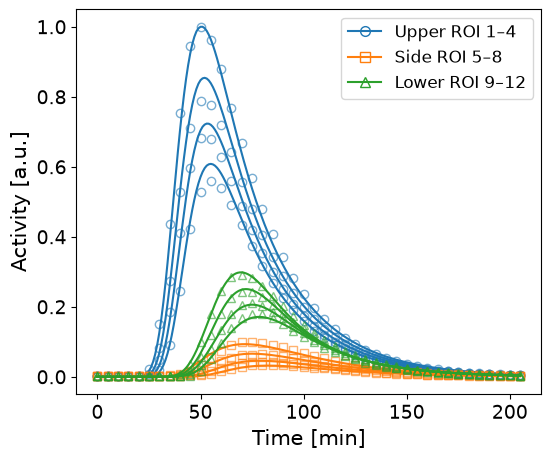

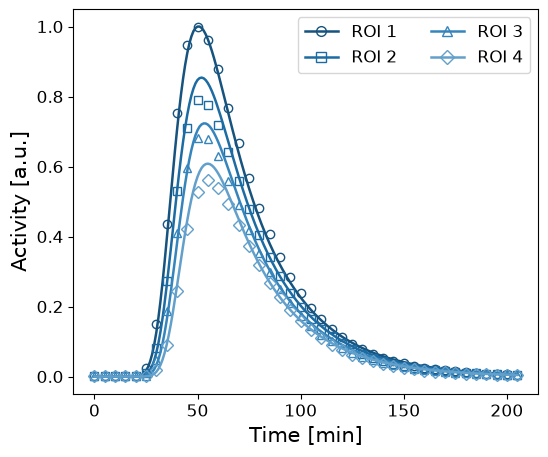

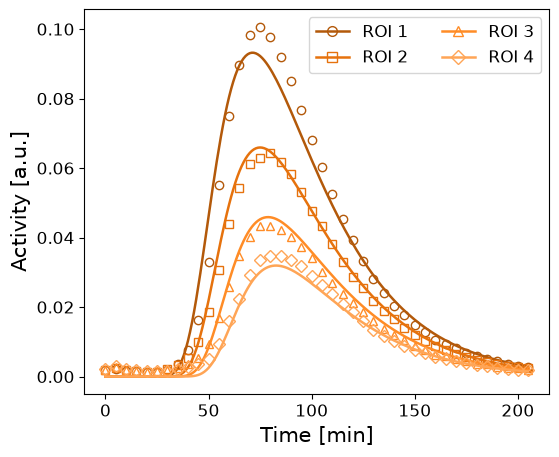

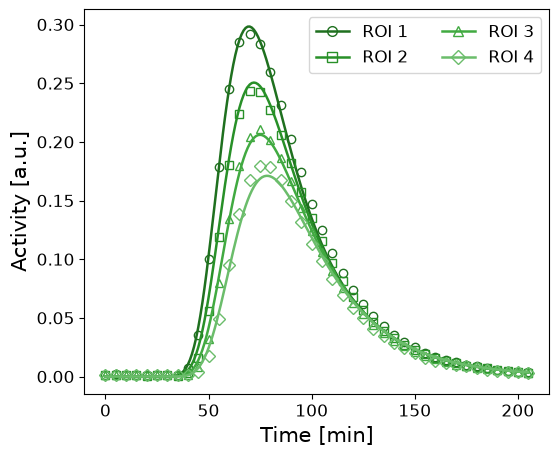

In [15]:
plot_for_publication(x_best_fit)


## Parameter uncertainties

Uses `pinv` (pseudo-inverse) for numerical stability. 

In [ ]:
param_uncertainties = compute_parameter_uncertainties(residuals, x_best_fit)
rel_param_uncertainties = param_uncertainties / np.abs(x_best_fit)

for name, uncertainty in zip(param_bounds.keys(), rel_param_uncertainties):
    print(f"{name:<30}±{uncertainty * 100:.4f}%")

/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
/home/IBT/lanzrath/CADET/CADET-Process/CADETP

volumetric_flow_rate_const    ±2.7506%
mct1_e12                      ±4.2714%
mct2_e12                      ±8.3250%
mct3_e12                      ±38.4048%
branch_point_side_quotia      ±1.2223%
col_dispersion                ±8.2033%
col_len                       ±3.4422%
t0                            ±0.0124%
mixer_porosity                ±3.1718%
branch_point_low_len          ±5.2991%
disp_low                      ±16.1252%


## Velocity Determination


In [16]:
best_x_phys = dict(zip(param_bounds.keys(), x_best_fit))
Q = best_x_phys['volumetric_flow_rate_const']       # m^3/s
quotia = best_x_phys['branch_point_side_quotia']    # side-branch flow fraction

v_upper = Q * 60000  # m/s -> mm/min (channel cross-section area = 1 m^2)
v_side = v_upper * quotia
v_lower = v_upper * (1 - quotia)

print(f"Upper velocity: {v_upper:.2f} mm/min")
print(f"Side velocity:  {v_side:.2f} mm/min")
print(f"Lower velocity: {v_lower:.2f} mm/min")


Upper velocity: 7.41 mm/min
Side velocity:  3.01 mm/min
Lower velocity: 4.40 mm/min
